<a href="https://colab.research.google.com/github/adarshabhattacharjee/comp_neuro_NMA/blob/main/W1D1_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#"How" models

In [1]:
# @title Install and import feedback gadget

!pip3 install vibecheck datatops --quiet

from vibecheck import DatatopsContentReviewContainer
def content_review(notebook_section: str):
    return DatatopsContentReviewContainer(
        "",  # No text prompt
        notebook_section,
        {
            "url": "https://pmyvdlilci.execute-api.us-east-1.amazonaws.com/klab",
            "name": "neuromatch_cn",
            "user_key": "y1x3mpx5",
        },
    ).render()


feedback_prefix = "W1D1_T2"

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 30.5 MB/s eta 0:00:00


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [3]:
# @title Figure Settings
import logging
logging.getLogger('matplotlib.font_manager').disabled = True

import ipywidgets as widgets  # interactive display
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.style.use("https://raw.githubusercontent.com/NeuromatchAcademy/course-content/main/nma.mplstyle")

In [4]:
# @title Plotting Functions

def histogram(counts, bins, vlines=(), ax=None, ax_args=None, **kwargs):
  """Plot a step histogram given counts over bins."""
  if ax is None:
    _, ax = plt.subplots()

  # duplicate the first element of `counts` to match bin edges
  counts = np.insert(counts, 0, counts[0])

  ax.fill_between(bins, counts, step="pre", alpha=0.4, **kwargs)  # area shading
  ax.plot(bins, counts, drawstyle="steps", **kwargs)  # lines

  for x in vlines:
    ax.axvline(x, color='r', linestyle='dotted')  # vertical line

  if ax_args is None:
    ax_args = {}

  # heuristically set max y to leave a bit of room
  ymin, ymax = ax_args.get('ylim', [None, None])
  if ymax is None:
    ymax = np.max(counts)
    if ax_args.get('yscale', 'linear') == 'log':
      ymax *= 1.5
    else:
      ymax *= 1.1
      if ymin is None:
        ymin = 0

  if ymax == ymin:
    ymax = None

  ax_args['ylim'] = [ymin, ymax]

  ax.set(**ax_args)
  ax.autoscale(enable=False, axis='x', tight=True)

def plot_neuron_stats(v, spike_times):
  fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

  # membrane voltage trace
  ax1.plot(v[0:100])
  ax1.set(xlabel='Time', ylabel='Voltage')
  # plot spike events
  for x in spike_times:
    if x >= 100:
      break
    ax1.axvline(x, color='red')

  # ISI distribution
  if len(spike_times)>1:
    isi = np.diff(spike_times)
    n_bins = np.arange(isi.min(), isi.max() + 2) - .5
    counts, bins = np.histogram(isi, n_bins)
    vlines = []
    if len(isi) > 0:
      vlines = [np.mean(isi)]
    xmax = max(20, int(bins[-1])+5)
    histogram(counts, bins, vlines=vlines, ax=ax2, ax_args={
      'xlabel': 'Inter-spike interval',
      'ylabel': 'Number of intervals',
      'xlim': [0, xmax]
    })
  else:
    ax2.set(xlabel='Inter-spike interval',
           ylabel='Number of intervals')
  plt.show()

---
# Section 1: The Linear Integrate-and-Fire Neuron


How does a neuron spike?

A neuron charges and discharges an electric field across its cell membrane. The state of this electric field can be described by the _membrane potential_. The membrane potential rises due to excitation of the neuron, and when it reaches a threshold a spike occurs. The potential resets, and must rise to a threshold again before the next spike occurs.


\begin{equation}
dV_m = {\alpha}I
\end{equation}

dVm = increase in membrane potential

I = input current (incoming signals)

α (alpha) = scaling factor (how strongly the input affects the neuron)

Once $V_m$ reaches a threshold value a spike is produced, $V_m$ is reset to a starting value, and the process continues.



Note that we define the membrane potential $V_m$ as a scalar: a single real (or floating point) number. However, a biological neuron's membrane potential will not be exactly constant at all points on its cell membrane at a given time. We could capture this variation with a more complex model (e.g. with more numbers). Do we need to?

The proposed model is a 1D simplification. There are many details we could add to it, to preserve different parts of the complex structure and dynamics of a real neuron. If we were interested in small or local changes in the membrane potential, our 1D simplification could be a problem. However, we'll assume an idealized "point" neuron model for our current purpose.

\begin{equation}
I \sim \mathrm{Poisson}(\lambda)
\end{equation}
The number of incoming spikes each timestep is chosen randomly according to a Poisson distribution

where $\lambda$ is the mean of the distribution: the average rate of spikes received per timestep.

A leaky integrate-and-fire neuron is a simplified model where random incoming spikes (modeled with a Poisson distribution) gradually increase the neuron's membrane potential according to dVm=αI. When the membrane potential reaches the threshold (1), the neuron fires a spike, resets to 0, and the process repeats.

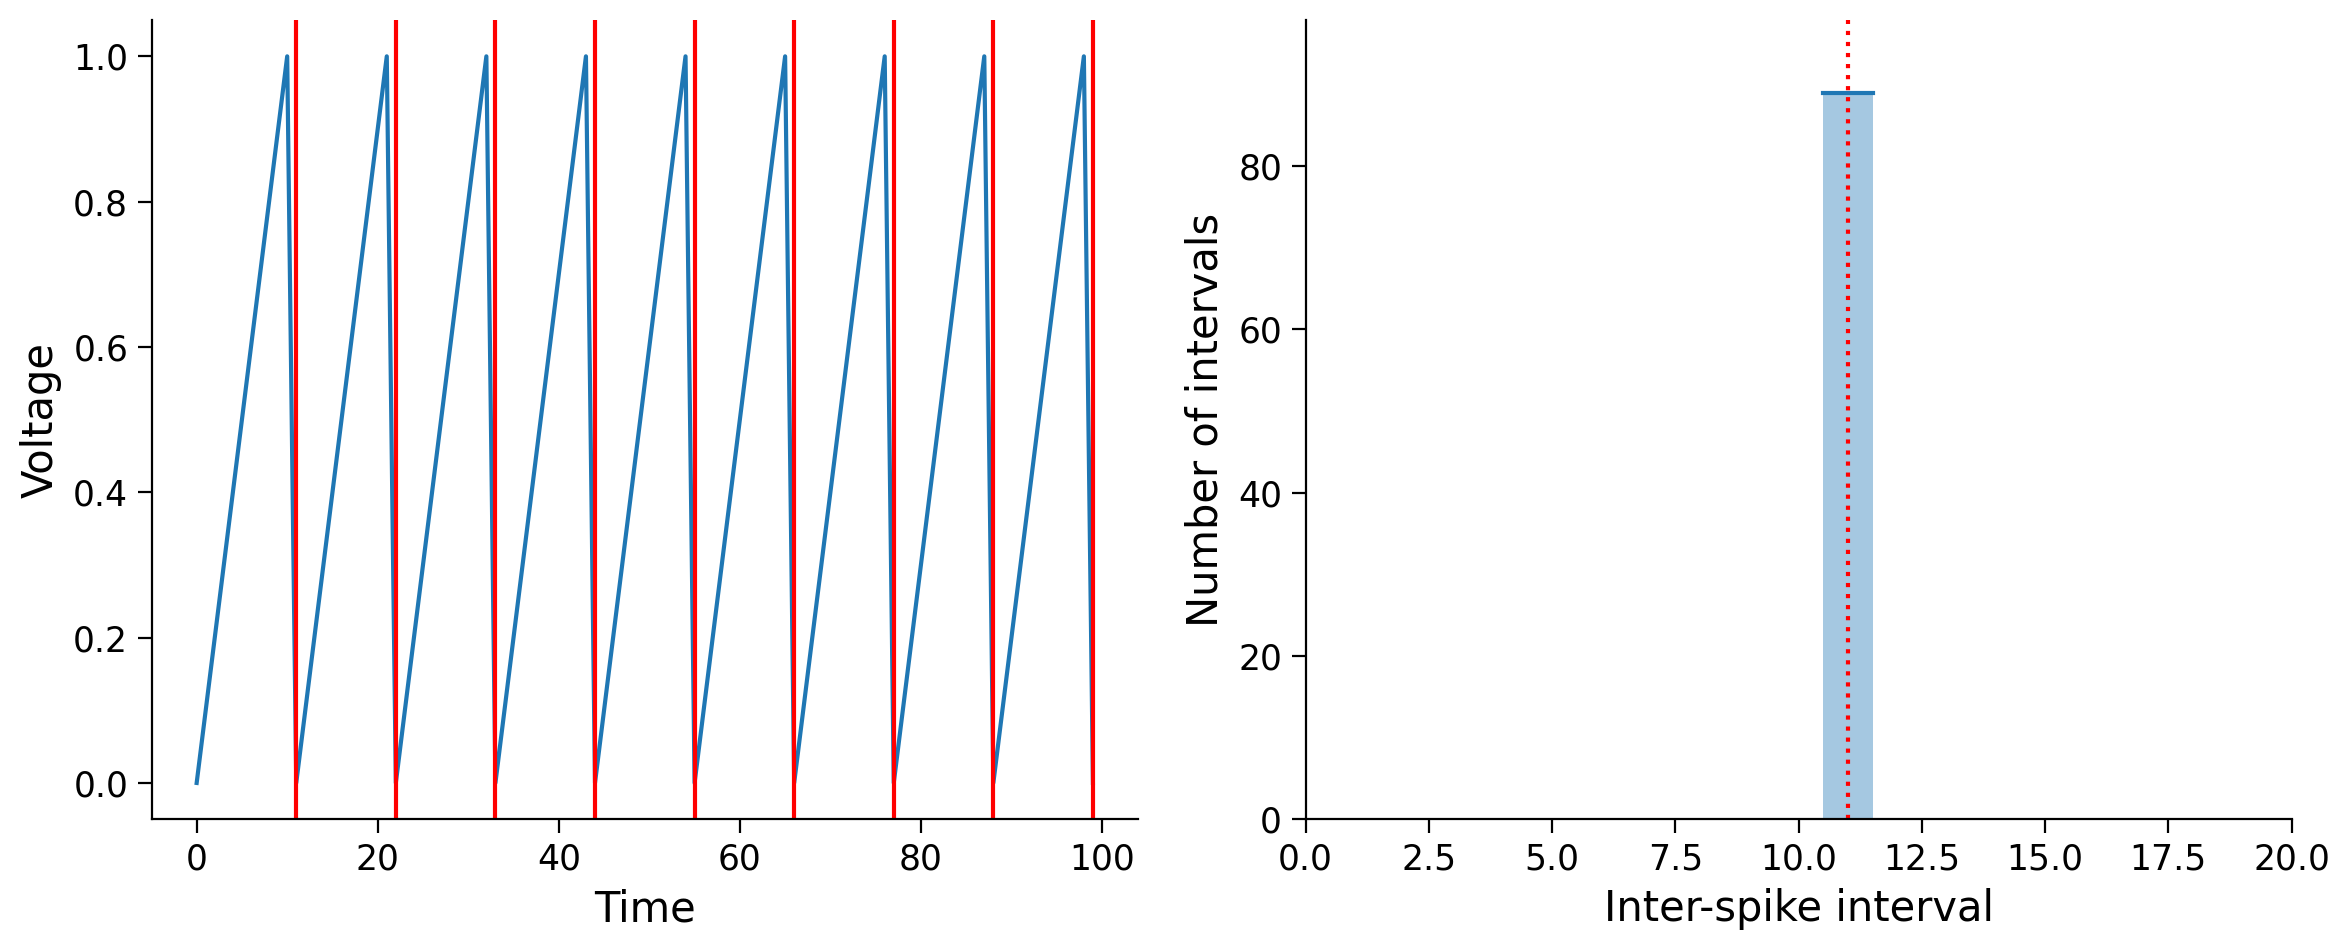

In [5]:
def lif_neuron(n_steps=1000, alpha=0.01, rate=10):
  """ Simulate a linear integrate-and-fire neuron.

  Args:
    n_steps (int): The number of time steps to simulate the neuron's activity.
    alpha (float): The input scaling factor
    rate (int): The mean rate of incoming spikes

  """
  # Precompute Poisson samples for speed
  exc = stats.poisson(rate).rvs(n_steps)

  # Initialize voltage and spike storage
  v = np.zeros(n_steps)
  spike_times = []

  ################################################################################
  # Students: compute dv, then comment out or remove the next line
  #raise NotImplementedError("Exercise: compute the change in membrane potential")
  ################################################################################

  # Loop over steps
  for i in range(1, n_steps):

    # Update v
    dv = alpha * rate
    v[i] = v[i-1] + dv

    # If spike happens, reset voltage and record
    if v[i] > 1:
      spike_times.append(i)
      v[i] = 0

  return v, spike_times

# Set random seed (for reproducibility)
np.random.seed(12)

# Model LIF neuron
v, spike_times = lif_neuron()

# Visualize
plot_neuron_stats(v, spike_times)

###interpretation
V threshold = 1V

V = V threshold (fire)

red line=spike



In [6]:
# @markdown You don't need to worry about how the code works – but you do need to **run the cell** to enable the sliders.

def _lif_neuron(n_steps=1000, alpha=0.01, rate=10):
  exc = stats.poisson(rate).rvs(n_steps)
  v = np.zeros(n_steps)
  spike_times = []
  for i in range(1, n_steps):
    dv = alpha * exc[i]
    v[i] = v[i-1] + dv
    if v[i] > 1:
      spike_times.append(i)
      v[i] = 0
  return v, spike_times

@widgets.interact(
  alpha=widgets.FloatLogSlider(0.01, min=-2, max=-1),
  rate=widgets.IntSlider(10, min=5, max=20)
)
def plot_lif_neuron(alpha=0.01, rate=10):
  v, spike_times = _lif_neuron(2000, alpha, rate)

  plot_neuron_stats(v, spike_times)

interactive(children=(FloatLogSlider(value=0.01, description='alpha', max=-1.0, min=-2.0), IntSlider(value=10,…

Raising alpha increases the rate of spikes (and thus decreases the inter-spike intervals)

Raising the rate increases the rate of spikes (and thus decreases the inter-spike intervals)
These two facts make sense because they both control the size of the input affecting the neuron - more
input means higher responses.


We know, however, that there are other factors that can drive $V_m$ down. First is the natural tendency of the neuron to return to some steady state or resting potential. We can update our previous model as follows:

\begin{equation}
dV_m = -{\beta}V_m + {\alpha}I
\end{equation}

where $V_m$ is the current membrane potential of the previous frame and $\beta$ is some leakage factor. This is a basic form of the popular Leaky

We also know that in addition to excitatory presynaptic neurons, we can have inhibitory presynaptic neurons as well. We can model these inhibitory neurons with another Poisson random variable:

\begin{align}
I &= I_{\mathrm{exc}} - I_{\mathrm{inh}} \\
I_{\mathrm{exc}} &\sim \mathrm{Poisson}(\lambda_{\mathrm{exc}}) \\
I_{\mathrm{inh}} &\sim \mathrm{Poisson}(\lambda_{\mathrm{inh}})
\end{align}

where $\lambda_{\mathrm{exc}}$ and $\lambda_{\mathrm{inh}}$ are the average spike rates (per timestep) of the excitatory and inhibitory presynaptic neurons, respectively.

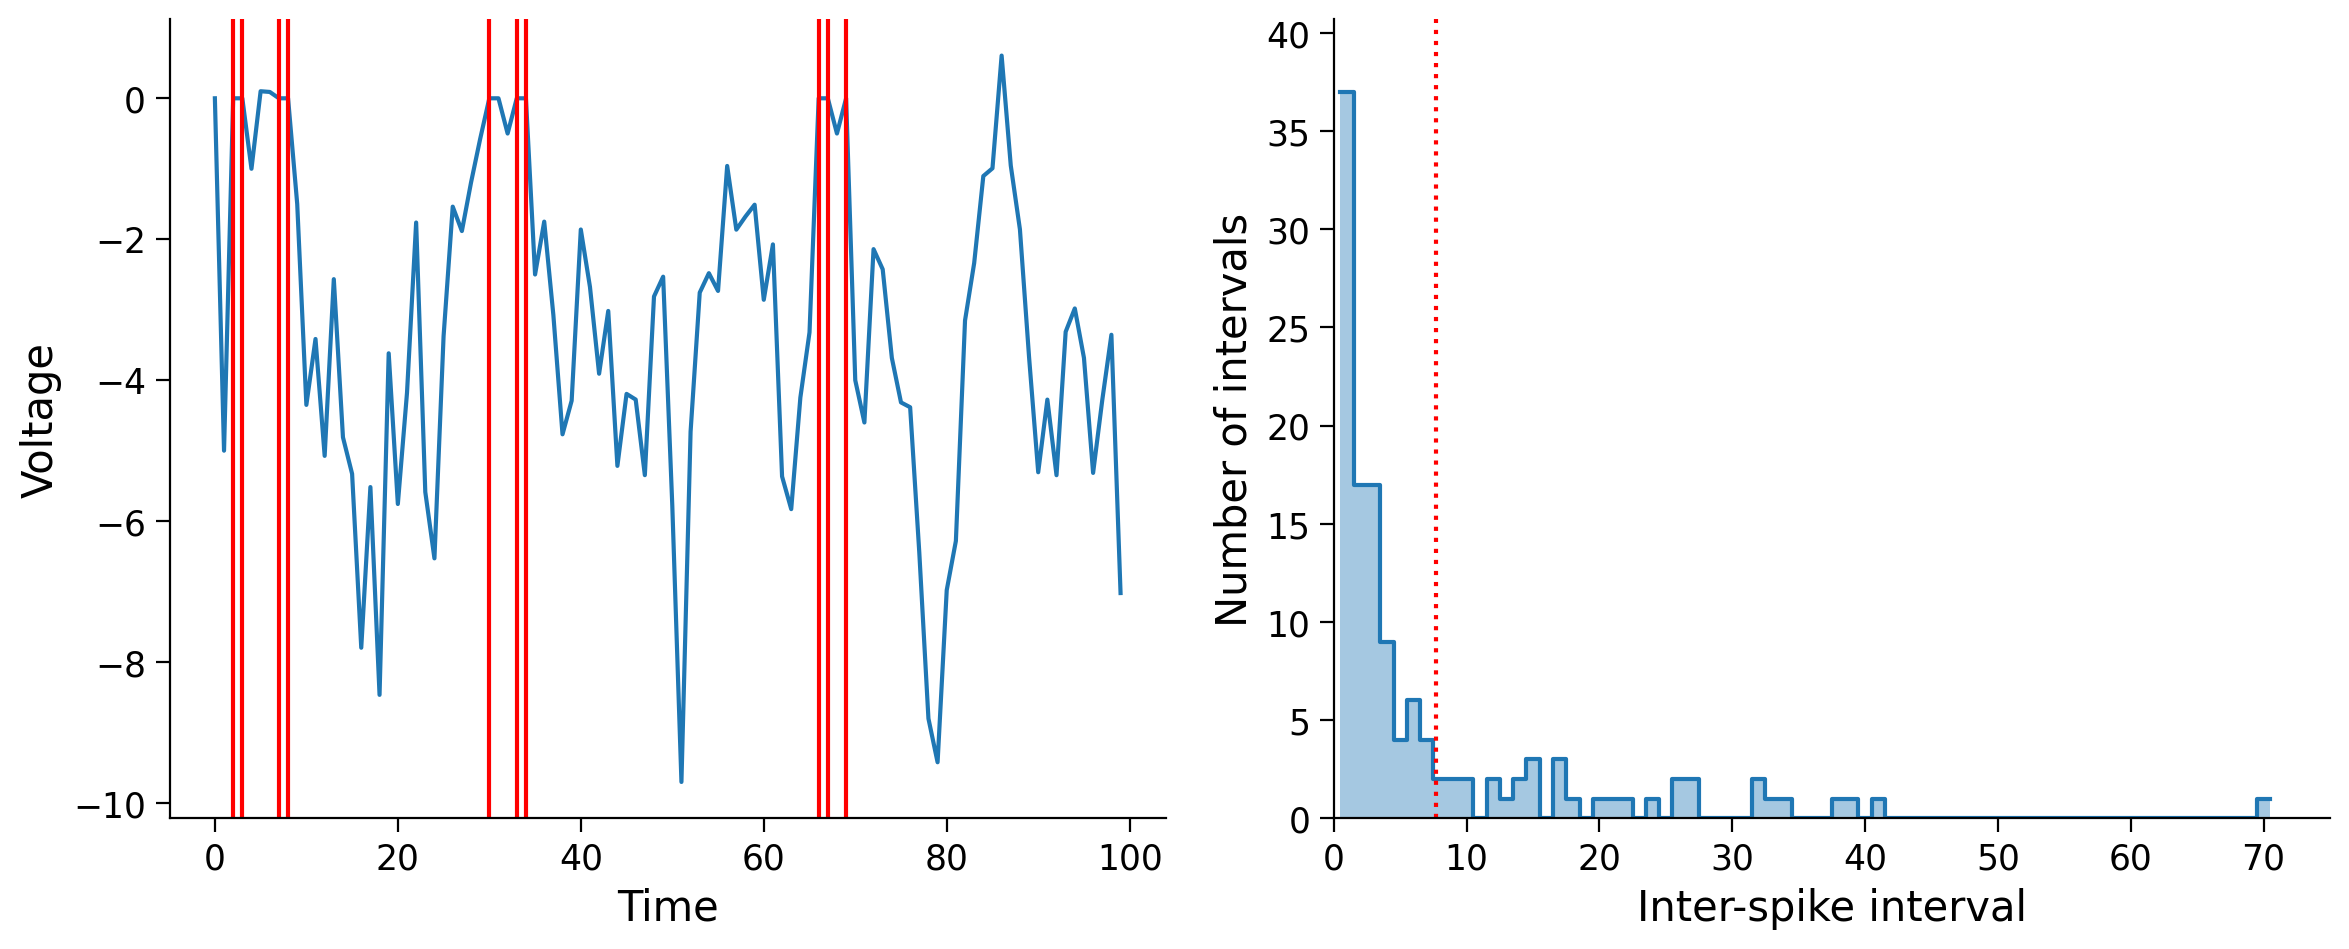

In [12]:
def lif_neuron_inh(n_steps=1000, alpha=0.5, beta=0.1, exc_rate=10, inh_rate=10):
  """ Simulate a simplified leaky integrate-and-fire neuron with both excitatory
  and inhibitory inputs.

  Args:
    n_steps (int): The number of time steps to simulate the neuron's activity.
    alpha (float): The input scaling factor
    beta (float): The membrane potential leakage factor
    exc_rate (int): The mean rate of the incoming excitatory spikes
    inh_rate (int): The mean rate of the incoming inhibitory spikes
  """

  # precompute Poisson samples for speed
  exc = stats.poisson(exc_rate).rvs(n_steps)
  inh = stats.poisson(inh_rate).rvs(n_steps)

  v = np.zeros(n_steps)
  spike_times = []

  ###############################################################################
  # Students: compute dv, then comment out or remove the next line
  #raise NotImplementedError("Exercise: compute the change in membrane potential")
  ################################################################################

  for i in range(1, n_steps):

    dv = alpha * (exc[i] - inh[i]) - beta * v[i-1]

    v[i] = v[i-1] + dv
    if v[i] > 1:
      spike_times.append(i)
      v[i] = 0

  return v, spike_times

# Set random seed (for reproducibility)
np.random.seed(12)

# Model LIF neuron
v, spike_times = lif_neuron_inh()

# Visualize
plot_neuron_stats(v, spike_times)

Raising the excitatory rate while keeping inhibitory rate the same results in
more frequent firing and shorter ISIs. This makes intuitive sense - more excitatory input
means higher responses.

Raising the inhibitory rate while keeping the excitatory rate the same results
in less frequent firing and longer ISIs. This makes intuitive sense - more inhibitory input
means lower responses.

If the excitatory and inhibitory rates are equal, the average inter-spike interval
stays the same even if you raise both. This is because they balance each other out.